<a href="https://colab.research.google.com/github/faisu6339-glitch/Deep-Learning/blob/main/ANN(Customer_Churn)_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [299]:
import pandas as pd

df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")   # Replace with your file name

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [300]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [301]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [302]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [303]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [304]:
df.shape

(7043, 21)

In [305]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

#1.Gender

In [306]:
df['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [307]:
gender_counts = df['gender'].value_counts()

In [308]:
gender_counts

,count
gender,
Male,3555
Female,3488


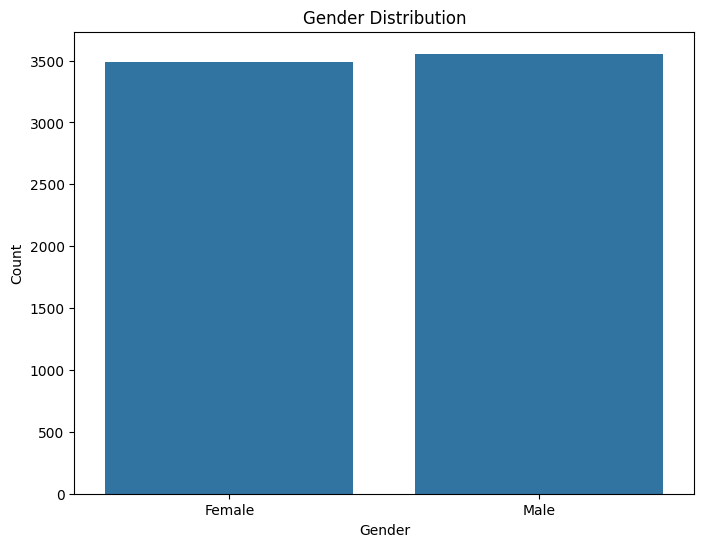

In [309]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='gender')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

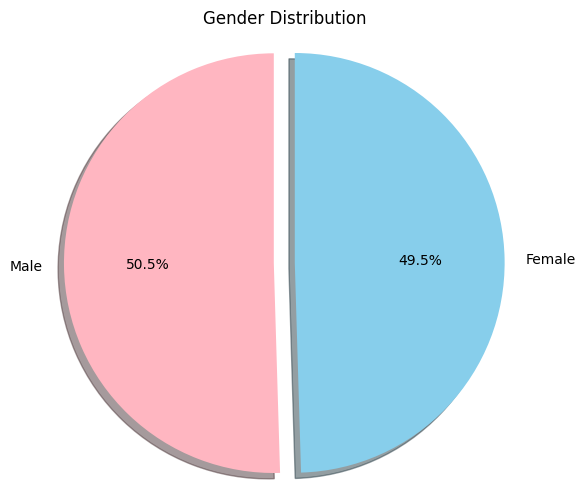

In [310]:
# Plot Pie Chart
plt.figure(figsize=(6,6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['lightpink', 'skyblue'],
    explode=(0.05, 0.05),
    shadow=True
)

plt.title("Gender Distribution")
plt.axis('equal')  # Makes the pie chart circular
plt.show()

#2.Senior Citizens

In [311]:
df['SeniorCitizen'].value_counts()

,count
SeniorCitizen,
0,5901
1,1142


In [312]:
senior_citizens=df['SeniorCitizen'].value_counts()

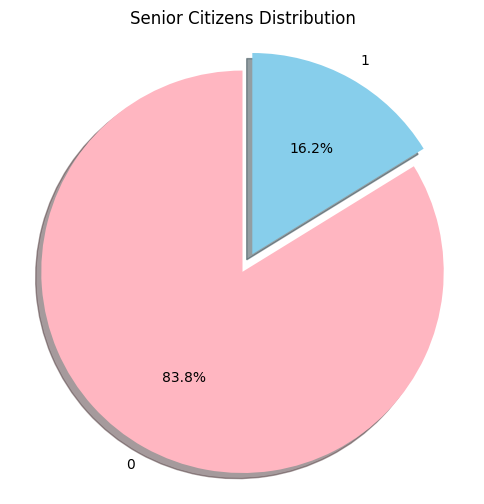

In [313]:
# Plot Pie Chart
plt.figure(figsize=(6,6))
plt.pie(
   senior_citizens,
    labels=senior_citizens.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['lightpink', 'skyblue'],
    explode=(0.05, 0.05),
    shadow=True
)

plt.title("Senior Citizens Distribution")
plt.axis('equal')  # Makes the pie chart circular
plt.show()

#'PaymentMethod'

In [314]:
df['PaymentMethod']

,PaymentMethod
0,Electronic check
1,Mailed check
2,Mailed check
3,Bank transfer (automatic)
4,Electronic check
...,...
7038,Mailed check
7039,Credit card (automatic)
7040,Electronic check
7041,Mailed check


In [315]:
df['PaymentMethod'].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [316]:
df['PaymentMethod'].value_counts()

,count
PaymentMethod,
Electronic check,2365
Mailed check,1612
Bank transfer (automatic),1544
Credit card (automatic),1522


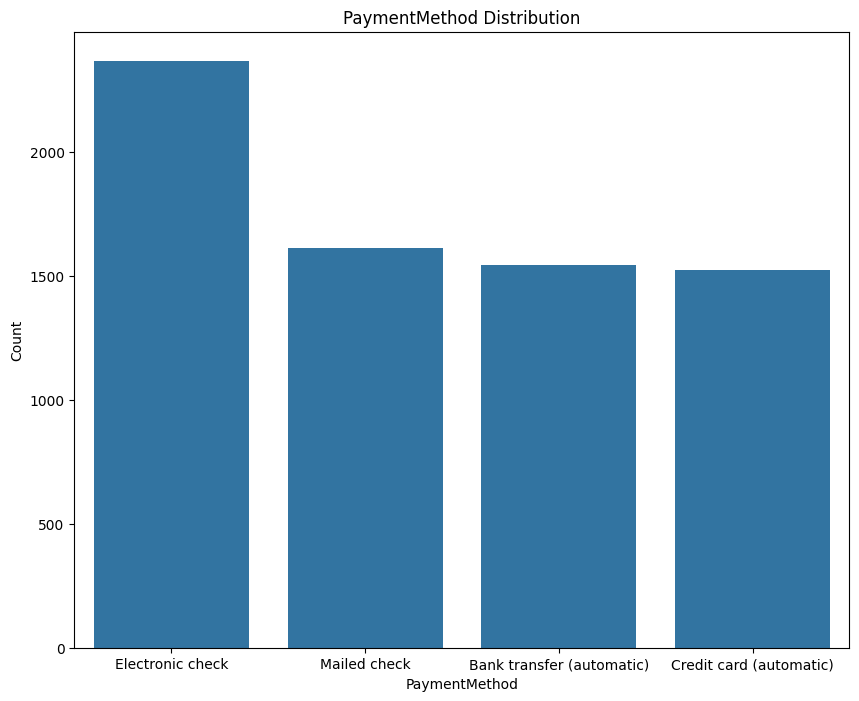

In [317]:
plt.figure(figsize=(10, 8))
sns.countplot(data=df, x='PaymentMethod')
plt.title('PaymentMethod Distribution')
plt.xlabel('PaymentMethod')
plt.ylabel('Count')
plt.show()

#Contracts

In [318]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [319]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


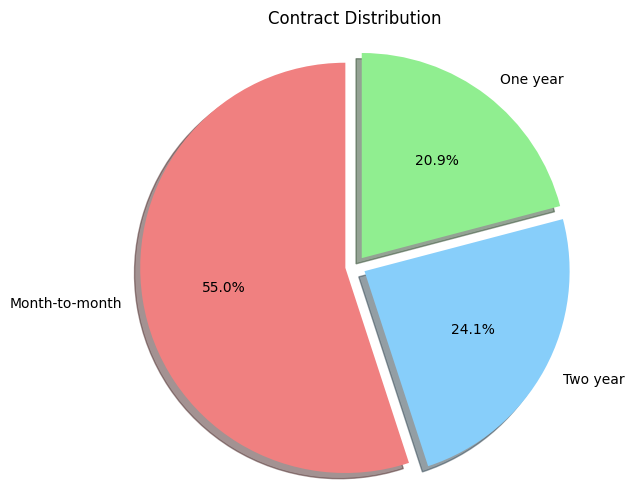

In [320]:
contract_counts = df['Contract'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    contract_counts,
    labels=contract_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['lightcoral', 'lightskyblue', 'lightgreen'],
    explode=(0.05, 0.05, 0.05),
    shadow=True
)

plt.title('Contract Distribution')
plt.axis('equal') # Makes the pie chart circular
plt.show()

#Numerical Columns

In [321]:
num_cols=df.select_dtypes(include=['int64','float64']).columns
print(num_cols)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')


#Categorical Columns

In [322]:
cat_cols = df.select_dtypes(include='object').columns

print(cat_cols)

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')


In [323]:
print("Numerical Columns:", len(num_cols))
print("Categorical Columns:", len(cat_cols))

Numerical Columns: 3
Categorical Columns: 18


### Data Cleaning: Convert `TotalCharges` to Numeric and Handle Missing Values

In [324]:
# Convert TotalCharges to numeric, coercing errors will turn non-numeric values into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for NaN values introduced by coercion
nan_total_charges = df['TotalCharges'].isnull().sum()
print(f"Number of NaN values in TotalCharges after conversion: {nan_total_charges}")

# Fill NaN values with the mean of TotalCharges
if nan_total_charges > 0:
    df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)
    print("NaN values in TotalCharges filled with the mean.")

# Verify the type conversion and no NaNs
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].isnull().sum())

Number of NaN values in TotalCharges after conversion: 11
NaN values in TotalCharges filled with the mean.
float64
0


/tmp/ipykernel_1523/3949712586.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)


### Visualizing Numerical Columns

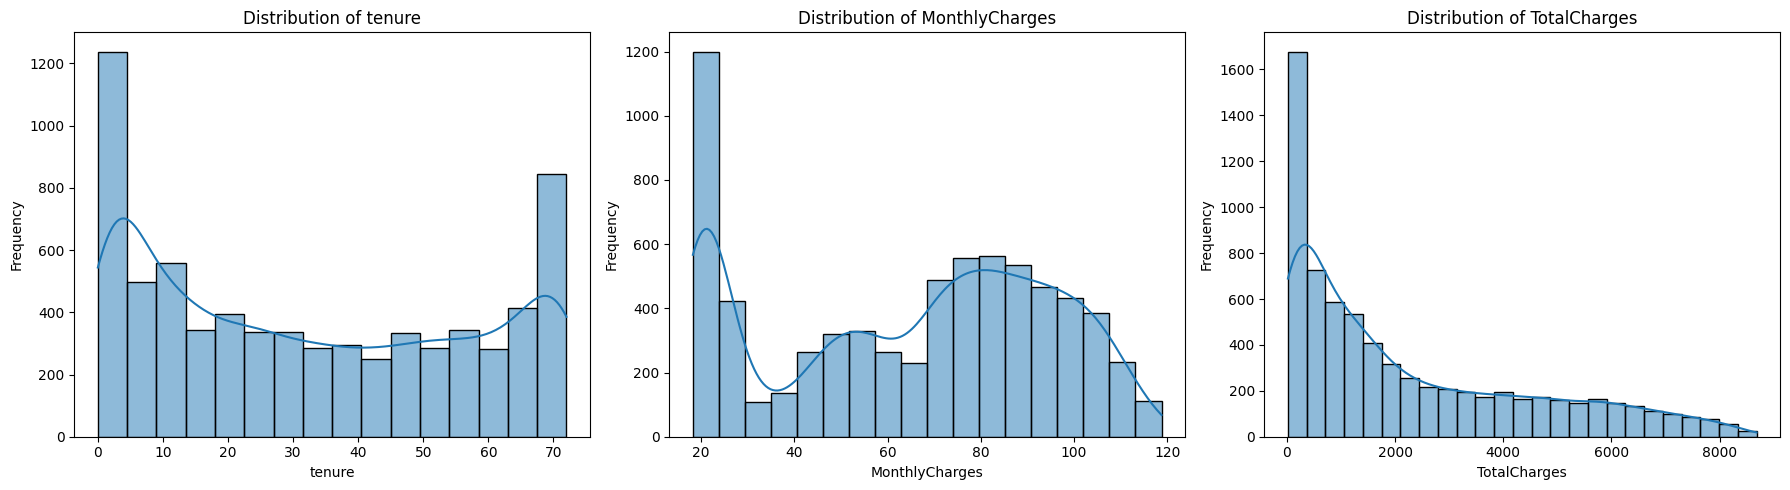

In [325]:
num_cols_to_plot = ['tenure', 'MonthlyCharges', 'TotalCharges'] # SeniorCitizen is already plotted as categorical

plt.figure(figsize=(18, 5))
for i, col in enumerate(num_cols_to_plot):
    plt.subplot(1, len(num_cols_to_plot), i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Visualizing Categorical Columns (Remaining)

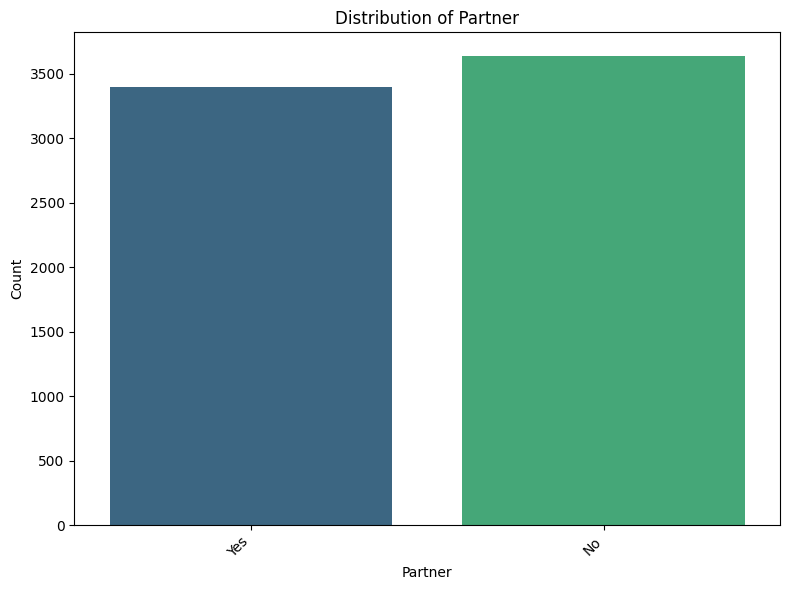

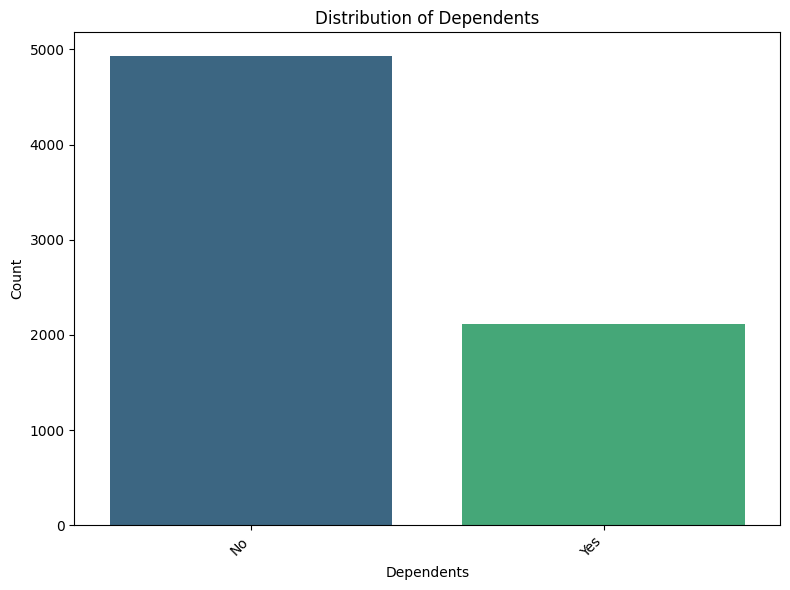

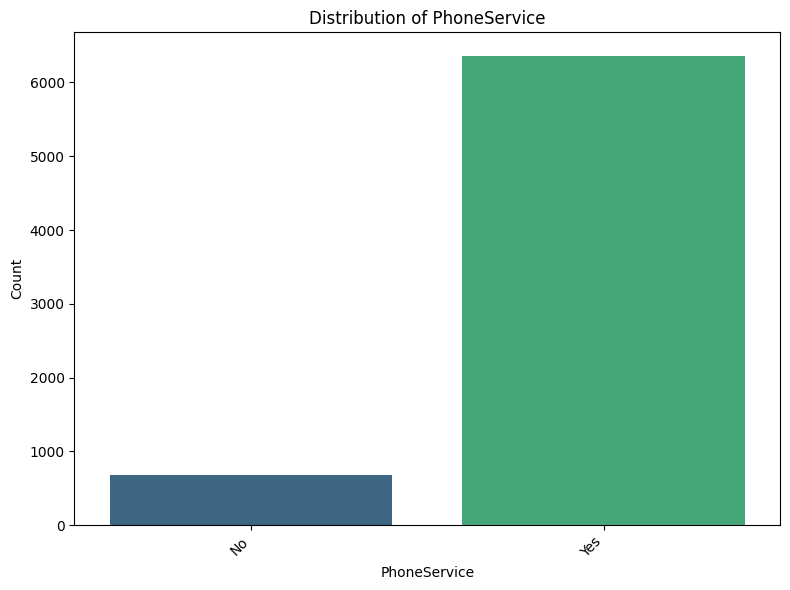

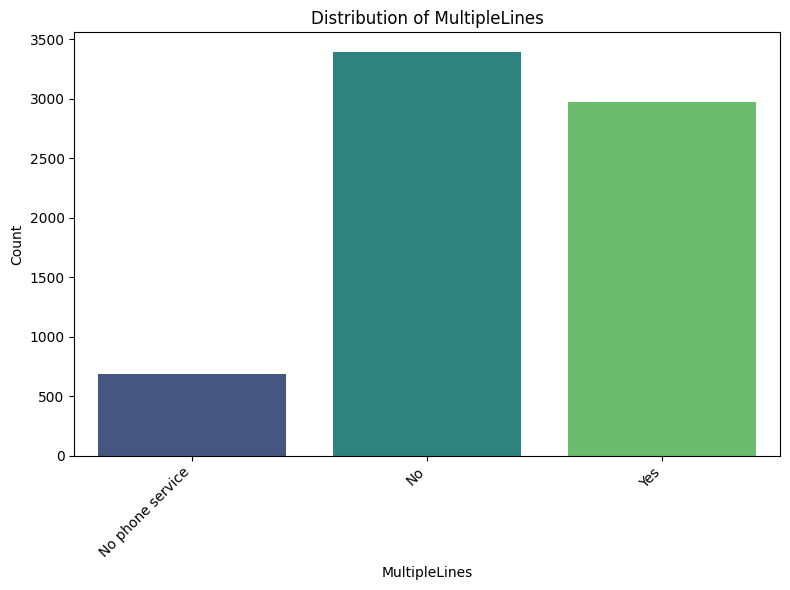

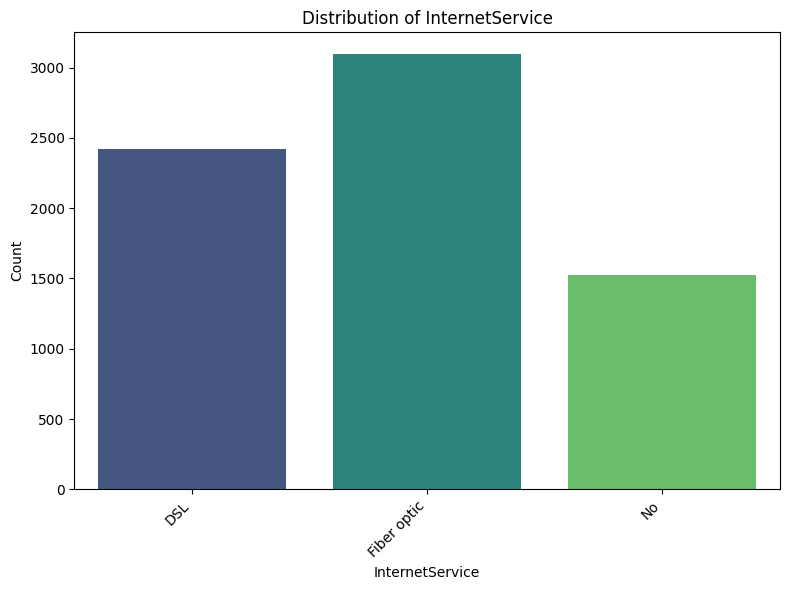

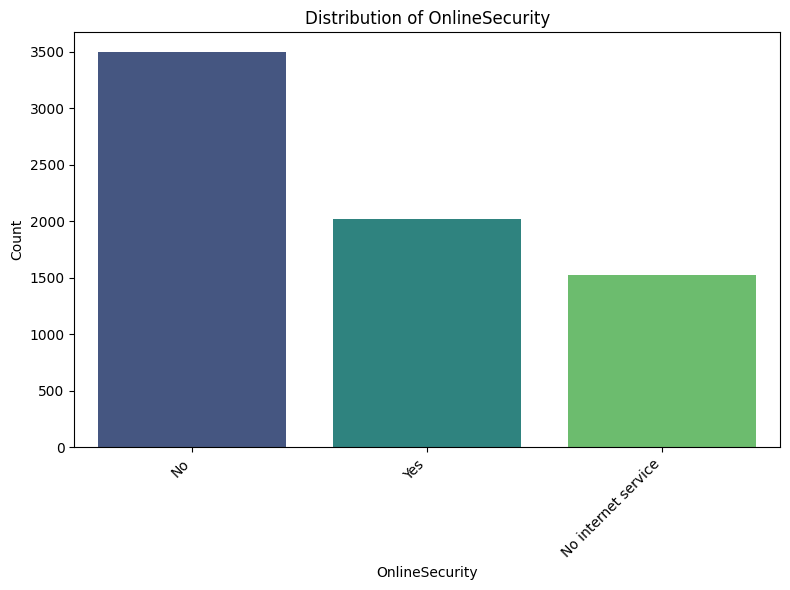

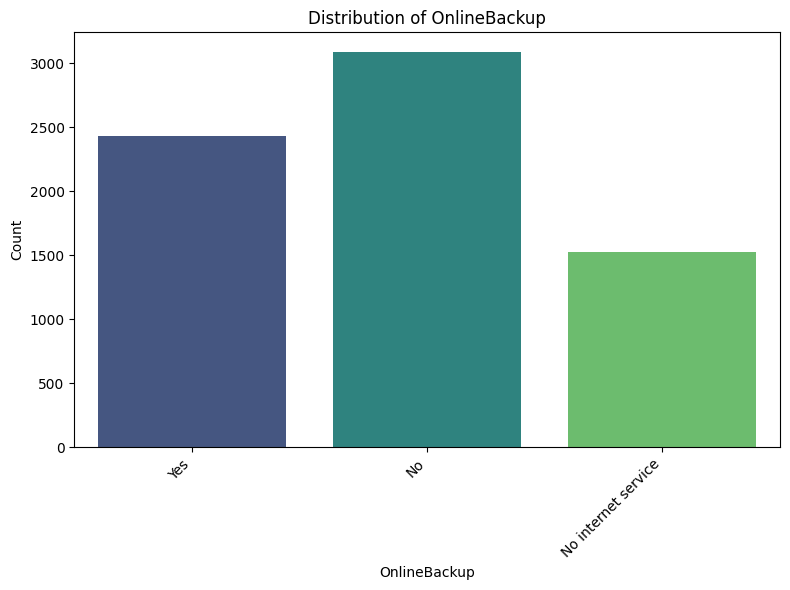

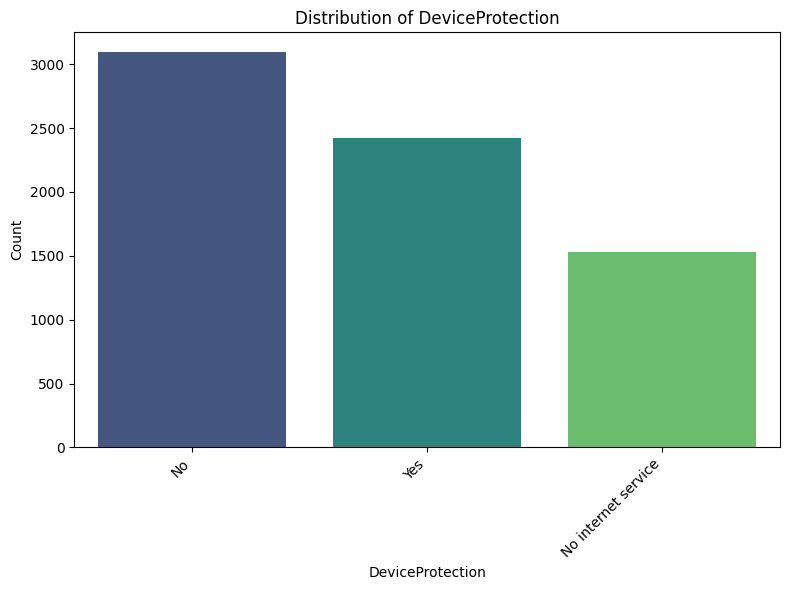

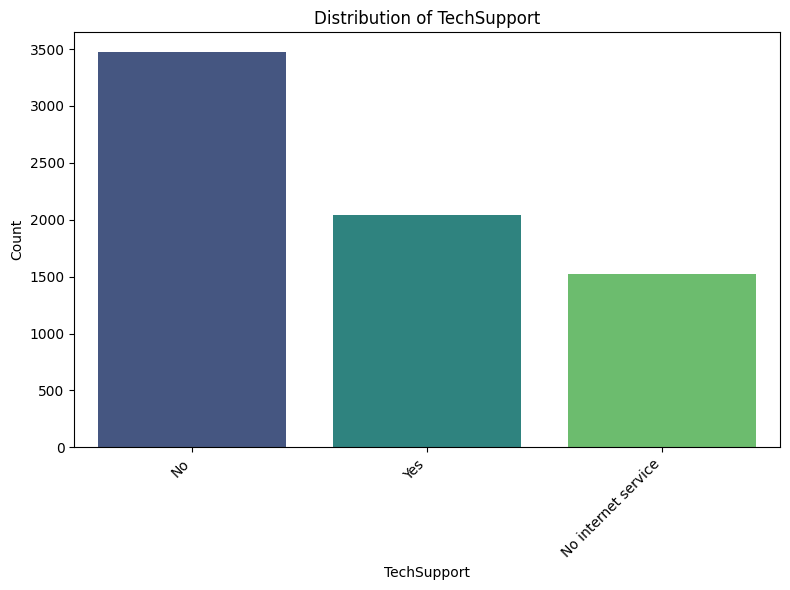

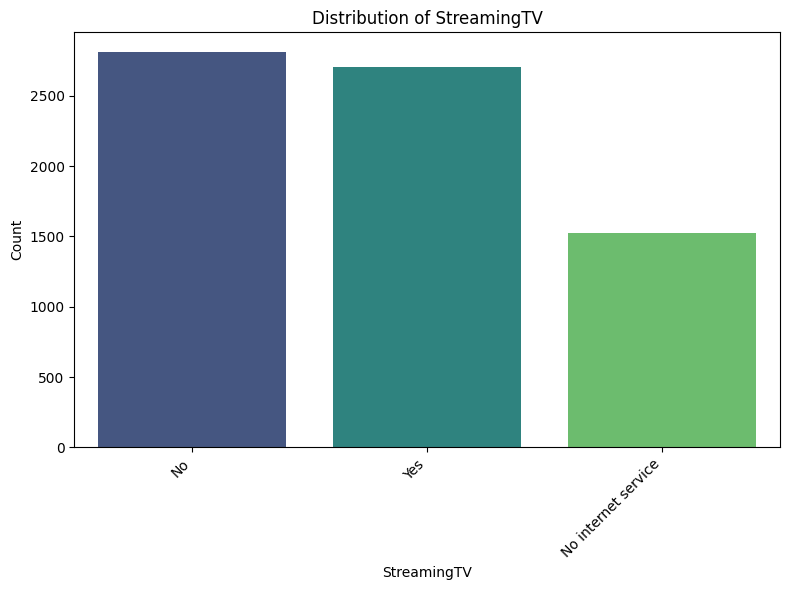

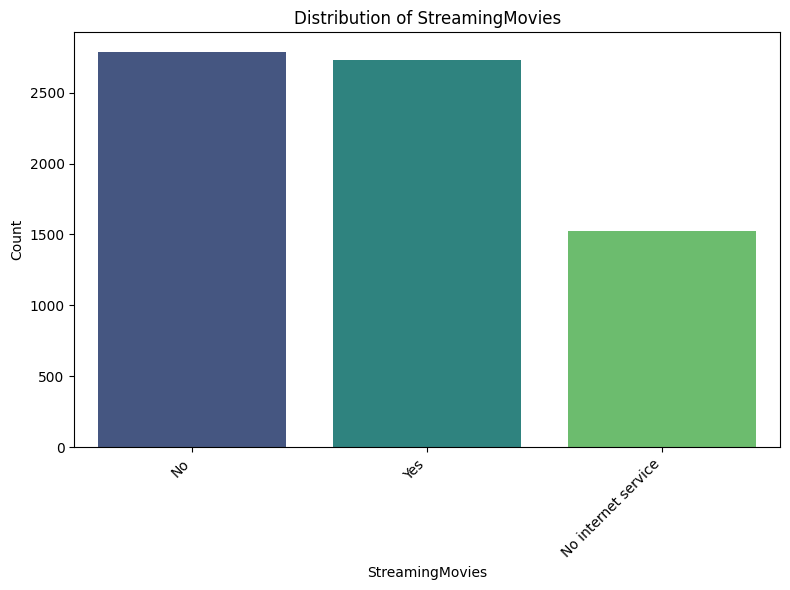

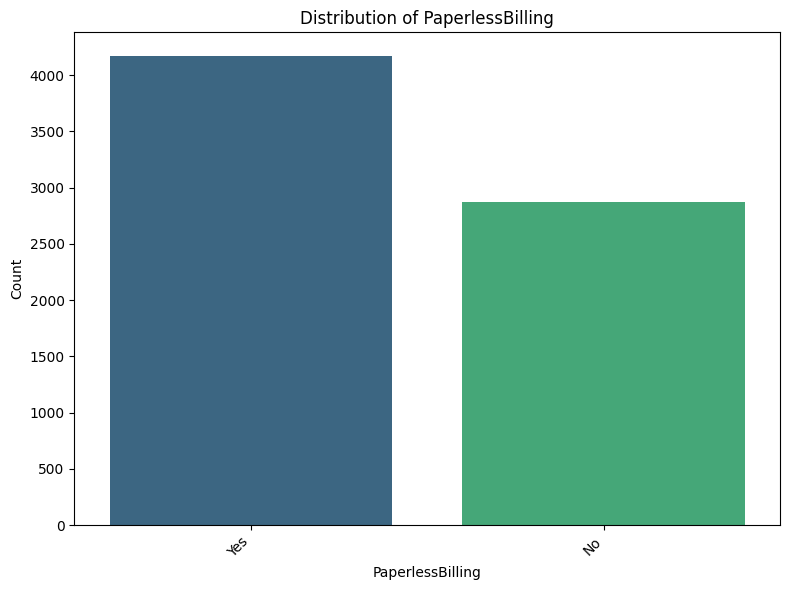

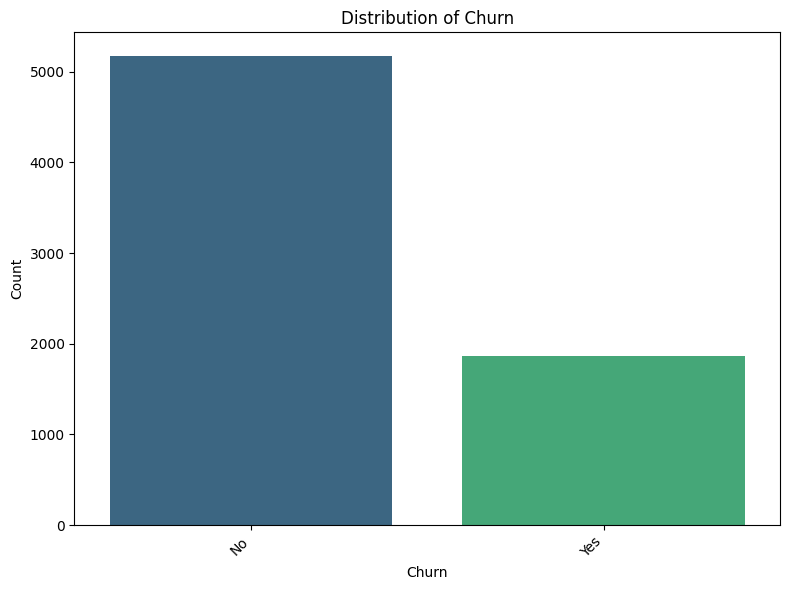

In [326]:
cat_cols_to_plot = [
    'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn'
]

# Iterate and create countplots for each categorical column
for col in cat_cols_to_plot:
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df, x=col, hue=col, palette='viridis', legend=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

#Check Outliers

#Method 1: Using the IQR (Best Method)

In [327]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}")
    print(f"Number of Outliers: {len(outliers)}")
    print("-" * 40)

SeniorCitizen
Number of Outliers: 1142
----------------------------------------
tenure
Number of Outliers: 0
----------------------------------------
MonthlyCharges
Number of Outliers: 0
----------------------------------------
TotalCharges
Number of Outliers: 0
----------------------------------------


#Method 2: Show the Outlier Rows

In [328]:
col = 'MonthlyCharges'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df[col] < lower) | (df[col] > upper)]

outliers

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


#Method 3: Using Z-Score

In [329]:
from scipy.stats import zscore

z_scores = zscore(df[num_cols])

outliers = (abs(z_scores) > 3)

print(outliers.sum(axis=0))

[0 0 0 0]


#Label Encoding

In [330]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["gender"] = le.fit_transform(df["gender"])


In [331]:
df['gender'].unique()

array([0, 1])

In [332]:
df['Partner']=le.fit_transform(df['Partner'])
df['Dependents']=le.fit_transform(df['Dependents'])
df['PhoneService']=le.fit_transform(df['PhoneService'])


In [333]:
print(df['MultipleLines'].unique())

#

['No phone service' 'No' 'Yes']


In [334]:
print(df['InternetService'].unique())


['DSL' 'Fiber optic' 'No']


In [335]:
df['PaperlessBilling'].unique()

array(['Yes', 'No'], dtype=object)

In [336]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['PaperlessBilling'] = le.fit_transform(df['PaperlessBilling'])

#: Encode All Columns at Once

In [337]:
multi_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

In [338]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,...,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.50,...,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,...,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,...,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,...,False,False,False,False,False,False,False,False,True,False


In [339]:
df.drop(columns=['customerID'], inplace=True)

#Feature Selection

In [340]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

### Label Encoding for 'Churn' (Target Variable)

Before splitting the data into features (X) and target (y), we need to convert the 'Churn' column from categorical strings ('Yes', 'No') to numerical representation (1, 0) using `LabelEncoder`. This is necessary for the Keras model to process the target variable correctly.

In [341]:
from sklearn.preprocessing import LabelEncoder

le_churn = LabelEncoder()
df['Churn'] = le_churn.fit_transform(df['Churn'])

print("Unique values in 'Churn' after encoding:", df['Churn'].unique())
print("Mapping: No -> 0, Yes -> 1")

Unique values in 'Churn' after encoding: [0 1]
Mapping: No -> 0, Yes -> 1


In [342]:
# Features
X = df.drop('Churn', axis=1)

# Target
y = df['Churn']

In [343]:
print(X.shape)
print(y.shape)

X.head()

(7043, 30)
(7043,)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,True,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,False,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,False,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,True,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,False,...,False,False,False,False,False,False,False,False,True,False


In [344]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#Scaling

In [345]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Import TensorFlow/Keras

In [346]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [347]:
from tensorflow.keras.callbacks import EarlyStopping

### Implement Early Stopping

We will now add an Early Stopping callback to the model training. This helps prevent overfitting by monitoring a chosen metric (e.g., `val_loss`) and stopping training if that metric stops improving for a specified number of epochs (`patience`). We'll also set `restore_best_weights=True` to ensure the model uses the weights from the epoch with the best performance on the validation set.

In [348]:
# Define the EarlyStopping callback
early_stopping_callback = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=5,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

#Model Building

In [349]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input

model = Sequential([
    Input(shape=(X_train.shape[1],)),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

In [350]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [351]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,993 (19.50 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 192 (768.00 B)

In [352]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stopping_callback] # Add the EarlyStopping callback here
)

Epoch 1/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7138 - loss: 0.5441 - val_accuracy: 0.7649 - val_loss: 0.4674
Epoch 2/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7708 - loss: 0.4557 - val_accuracy: 0.7711 - val_loss: 0.4464
Epoch 3/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7837 - loss: 0.4399 - val_accuracy: 0.7702 - val_loss: 0.4476
Epoch 4/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7912 - loss: 0.4324 - val_accuracy: 0.7728 - val_loss: 0.4494
Epoch 5/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7919 - loss: 0.4336 - val_accuracy: 0.7764 - val_loss: 0.4441
Epoch 6/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7961 - loss: 0.4255 - val_accuracy: 0.7764 - val_loss: 0.4439
Epoch 7/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8025 - loss: 0.4190 - val_accuracy: 0.7737 - val_loss: 0.4442
Epoch 8/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7990 - loss: 0.4220 - val_accuracy: 0

### Evaluate Model Performance on Test Data

In [353]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

Test Loss: 0.4248
Test Accuracy: 0.7913


### Visualize Training History

Plotting the training and validation accuracy and loss over epochs can help in understanding the model's learning behavior and detecting overfitting.

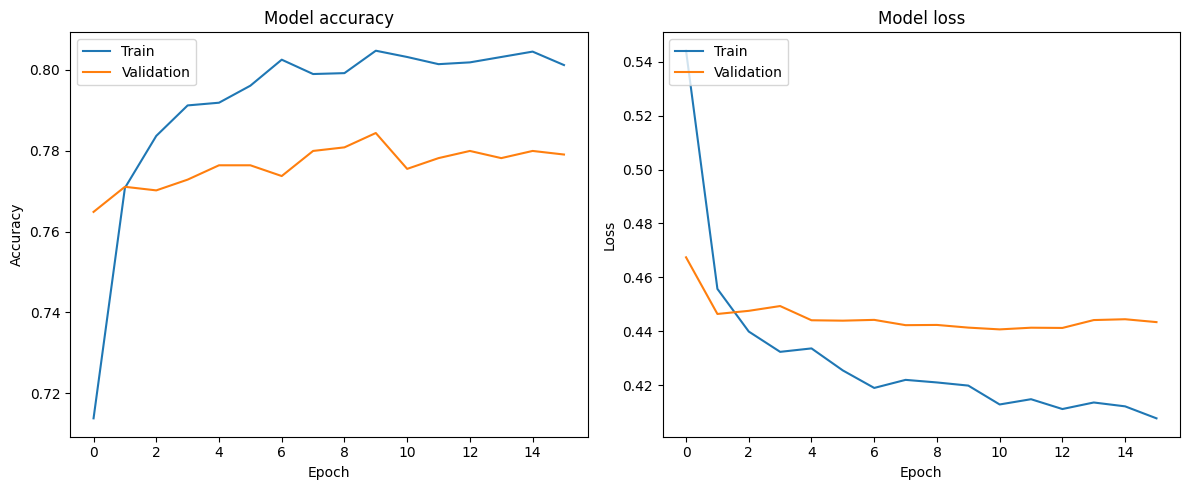

In [354]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [355]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7913 - loss: 0.4248
Test Loss: 0.4247845411300659
Test Accuracy: 0.7913413643836975


In [356]:
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [357]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[900 135]
 [159 215]]


#confusion Matrix

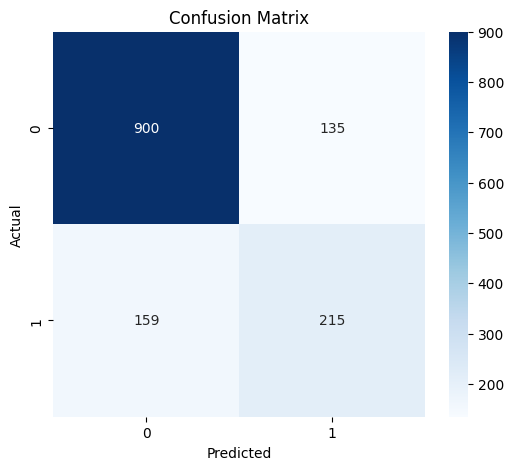

In [358]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

#Classification_report

In [359]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1035
           1       0.61      0.57      0.59       374

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.73      1409
weighted avg       0.79      0.79      0.79      1409



#ROC_Curve

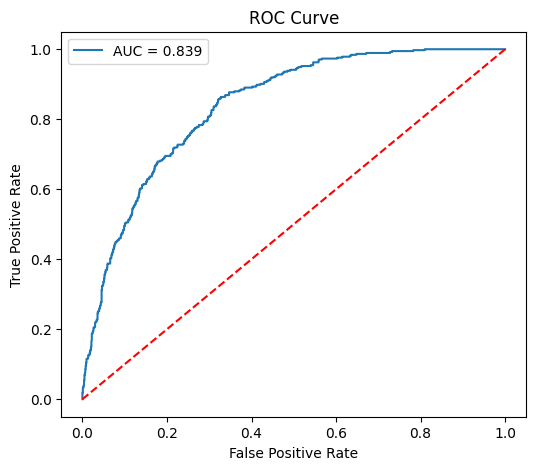

In [360]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

### Generate Predictions on New Data

To generate predictions, you would typically feed new, unseen data (preprocessed in the same way as your training data) into the `model.predict()` method. Here, we'll demonstrate using our `X_test` set.

In [361]:
# Generate probability predictions on the test set
new_predictions_prob = model.predict(X_test)

# Convert probabilities to binary class labels (0 or 1) using a threshold of 0.5
new_predictions_binary = (new_predictions_prob > 0.5).astype(int)

print("Sample of new probability predictions (first 10):\n", new_predictions_prob[:10])
print("\nSample of new binary predictions (first 10):\n", new_predictions_binary[:10])

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Sample of new probability predictions (first 10):
 [[0.03588648]
 [0.7279538 ]
 [0.04408569]
 [0.33987793]
 [0.01915537]
 [0.5878839 ]
 [0.53025556]
 [0.10111641]
 [0.00317739]
 [0.46016055]]

Sample of new binary predictions (first 10):
 [[0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]]


In [367]:
print(X.columns)
print(len(X.columns))

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')
30


In [371]:
for i, col in enumerate(X.columns):
    print(i, col)

0 gender
1 SeniorCitizen
2 Partner
3 Dependents
4 tenure
5 PhoneService
6 PaperlessBilling
7 MonthlyCharges
8 TotalCharges
9 MultipleLines_No phone service
10 MultipleLines_Yes
11 InternetService_Fiber optic
12 InternetService_No
13 OnlineSecurity_No internet service
14 OnlineSecurity_Yes
15 OnlineBackup_No internet service
16 OnlineBackup_Yes
17 DeviceProtection_No internet service
18 DeviceProtection_Yes
19 TechSupport_No internet service
20 TechSupport_Yes
21 StreamingTV_No internet service
22 StreamingTV_Yes
23 StreamingMovies_No internet service
24 StreamingMovies_Yes
25 Contract_One year
26 Contract_Two year
27 PaymentMethod_Credit card (automatic)
28 PaymentMethod_Electronic check
29 PaymentMethod_Mailed check


In [372]:
new_customer = [[
    1,      # gender
    0,      # SeniorCitizen
    1,      # Partner
    0,      # Dependents
    24,     # tenure
    1,      # PhoneService
    1,      # PaperlessBilling
    70.0,   # MonthlyCharges
    1700.0, # TotalCharges

    # MultipleLines
    0,
    1,

    # InternetService
    1,
    0,

    # OnlineSecurity
    0,
    1,

    # OnlineBackup
    0,
    1,

    # DeviceProtection
    0,
    0,

    # TechSupport
    0,
    1,

    # StreamingTV
    0,
    1,

    # StreamingMovies
    0,
    0,

    # Contract
    1,
    0,

    # PaymentMethod
    1,
    0,
    0
]]

In [374]:
new_customer = scaler.transform(new_customer)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [375]:
prediction = model.predict(new_customer)

print("Probability:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Customer will Churn")
else:
    print("Customer will NOT Churn")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Probability: 0.13465716
Customer will NOT Churn


### Predict Churn for the New Customer

Now, let's use our trained model to predict the churn probability and the binary churn status for the `new_customer`.

In [376]:
new_customer = pd.DataFrame([[
    1,0,1,0,24,1,1,70.0,1700.0,
    0,1,
    1,0,
    0,1,
    0,1,
    0,0,
    0,1,
    0,1,
    0,0,
    1,0,
    1,0,0
]], columns=X.columns)

In [377]:
new_customer_scaled = scaler.transform(new_customer)

prediction = model.predict(new_customer_scaled)

print("Churn Probability:", prediction[0][0])

if prediction[0][0] >= 0.5:
    print("Prediction: Customer will Churn")
else:
    print("Prediction: Customer will Not Churn")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Churn Probability: 0.20352472
Prediction: Customer will Not Churn
